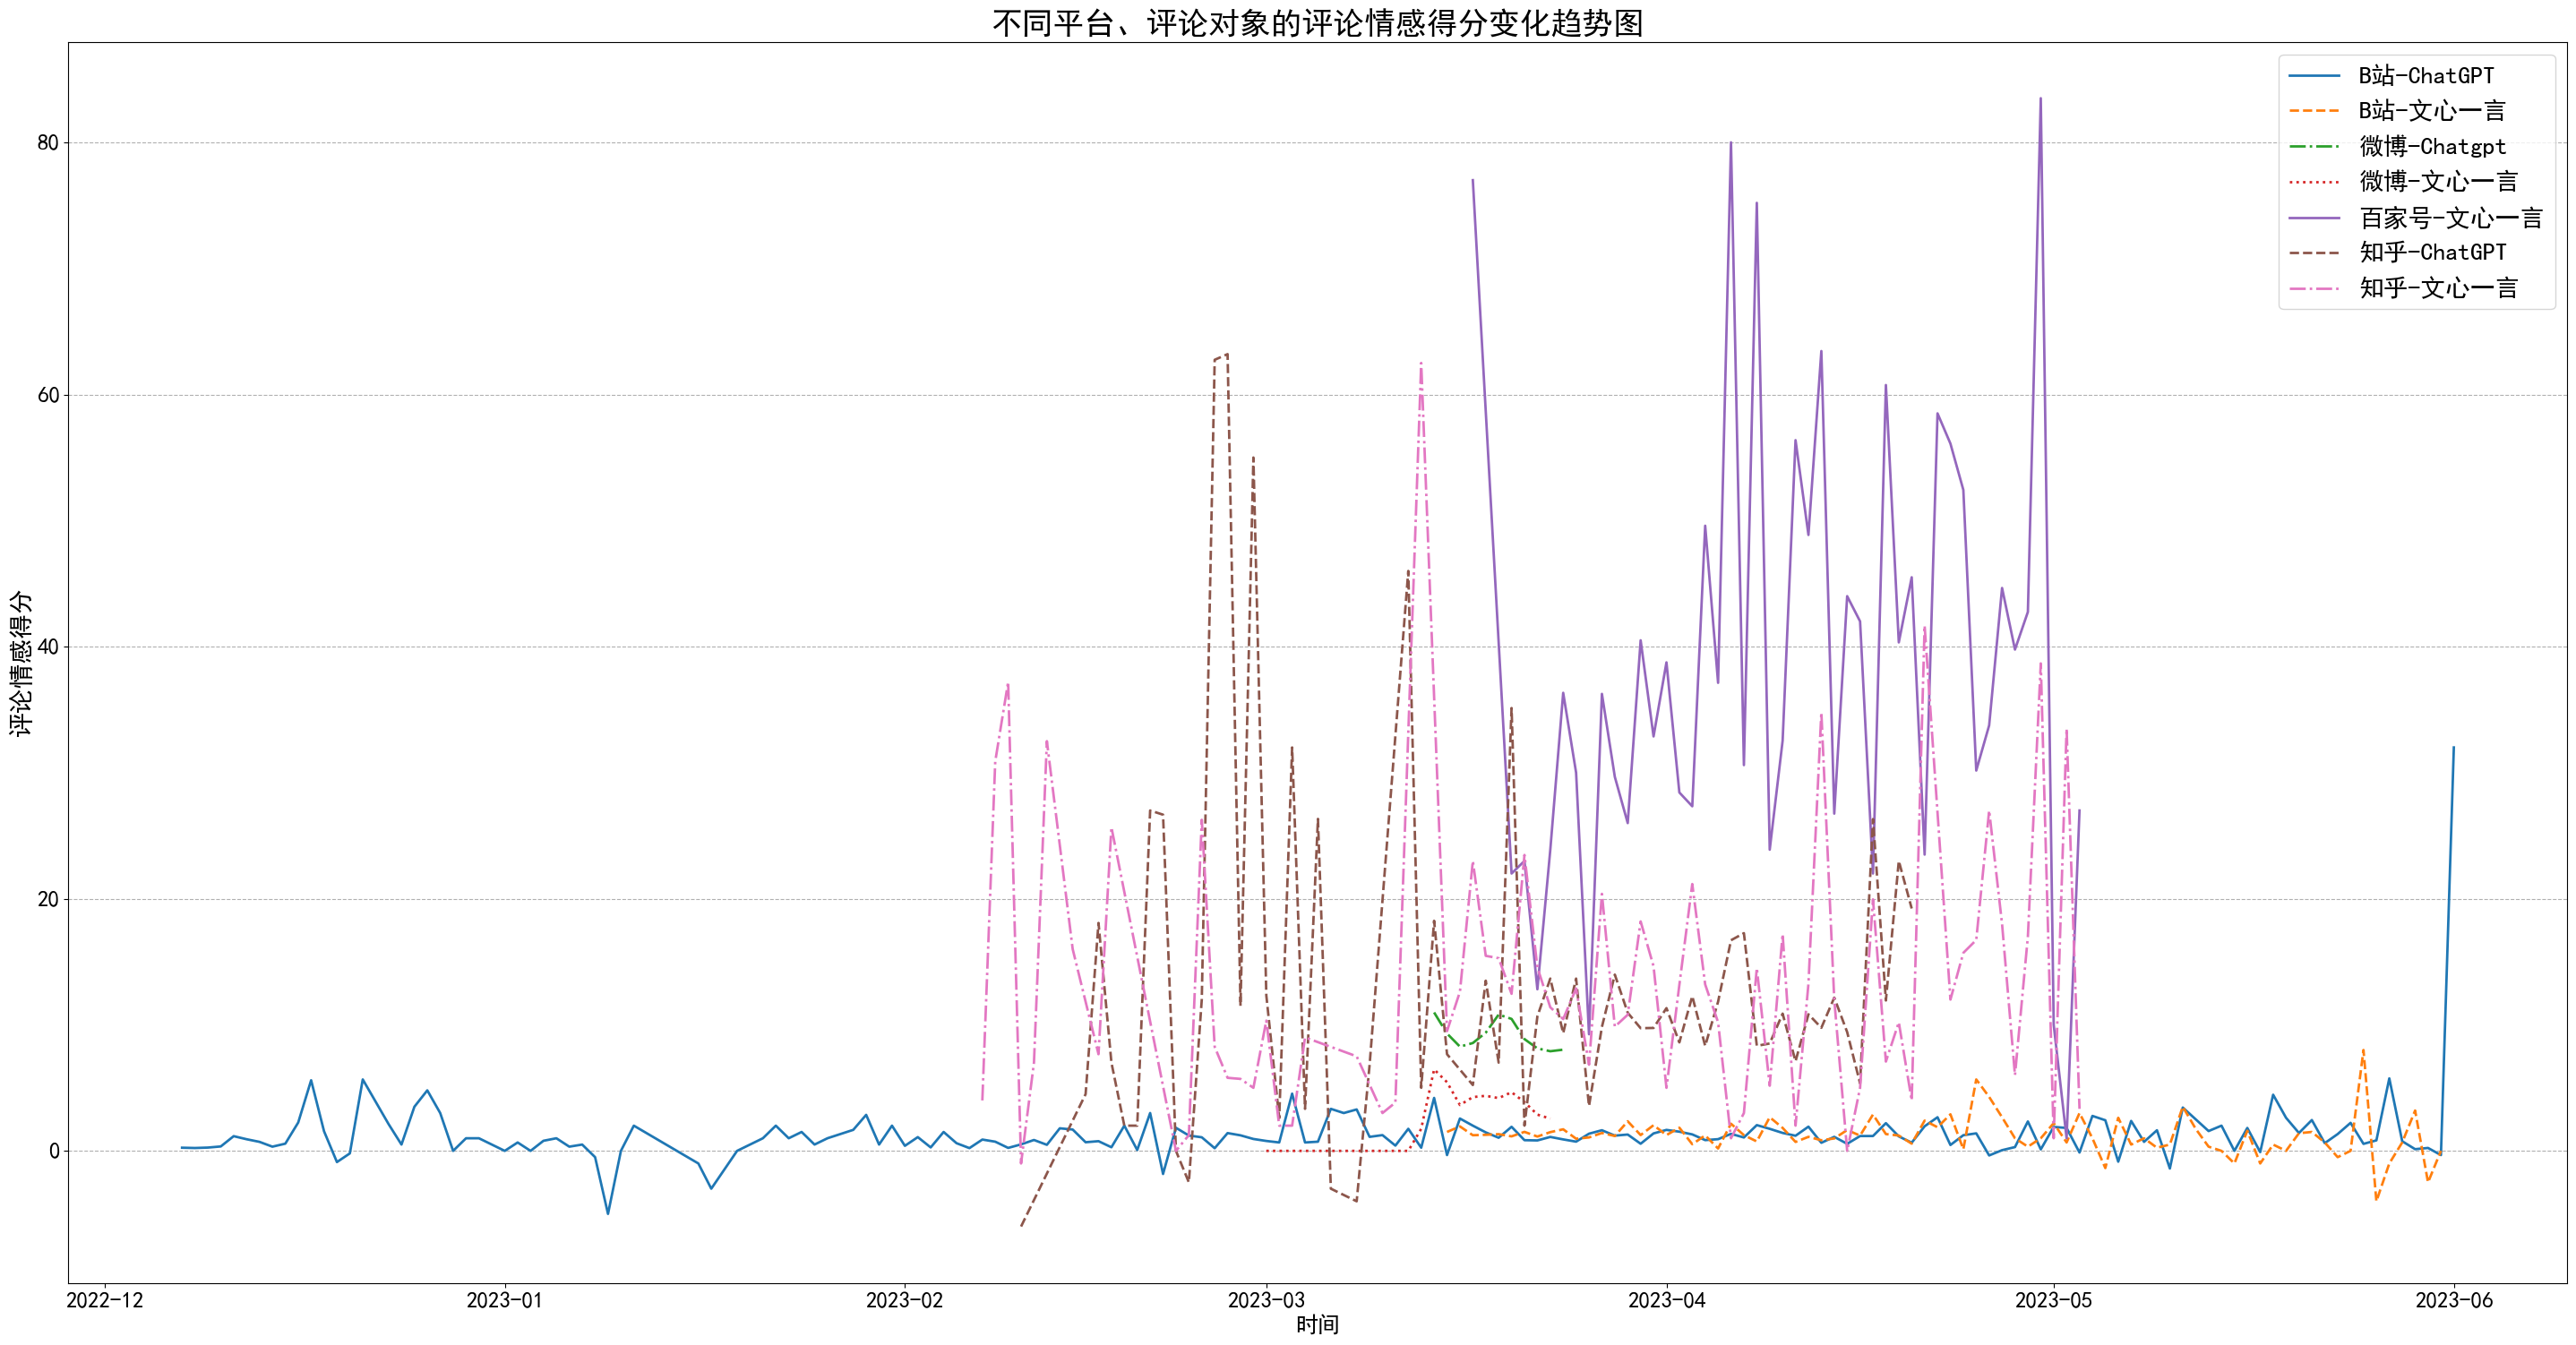

In [2]:
#绘制所有平台对于“文心一言”和“ChatGPT”的平均每日评论情感得分变化趋势图
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = ['SimHei']  # 设置中文字体为Arial Unicode MS
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

# 加载数据
data = pd.read_csv(r"C:\py study\data ana hw\情感分析绘图\merged_file_2.csv")

# 将评论时间转换为日期格式
data['评论时间'] = pd.to_datetime(data['评论时间'], format='%Y/%m/%d')

# 根据不同平台和评论对象计算平均情感得分
grouped = data.groupby(['用户所属平台', '评论对象', pd.Grouper(key='评论时间', freq='1D')])['评论情感得分'].mean().reset_index()

# 绘制图表
fig, ax = plt.subplots(figsize=(36, 18))

# 绘制不同平台、评论对象的评论情感得分变化趋势
linestyles = ['-', '--', '-.', ':']  # 线条样式
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']  # 线条颜色
i = 0
for platform, group in grouped.groupby('用户所属平台'):
    for comment_obj, sub_group in group.groupby('评论对象'):
        ax.plot(sub_group['评论时间'], sub_group['评论情感得分'], label=f"{platform}-{comment_obj}", linestyle=linestyles[i % len(linestyles)], color=colors[i % len(colors)], linewidth=2)
        i += 1

# 设置坐标轴标签和标题
ax.set_xlabel('时间', fontsize=18)
ax.set_ylabel('评论情感得分', fontsize=20)
ax.set_title('不同平台、评论对象的评论情感得分变化趋势图', fontsize=25)

# 设置坐标轴刻度标签和网格线
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(axis='y', linestyle='--')
ax.tick_params(axis='y', labelsize=18)
ax.tick_params(axis='x', labelsize=18)
# 设置图例标签和字体大小
ax.legend(prop={'size': 20})

# 显示图形
plt.show()

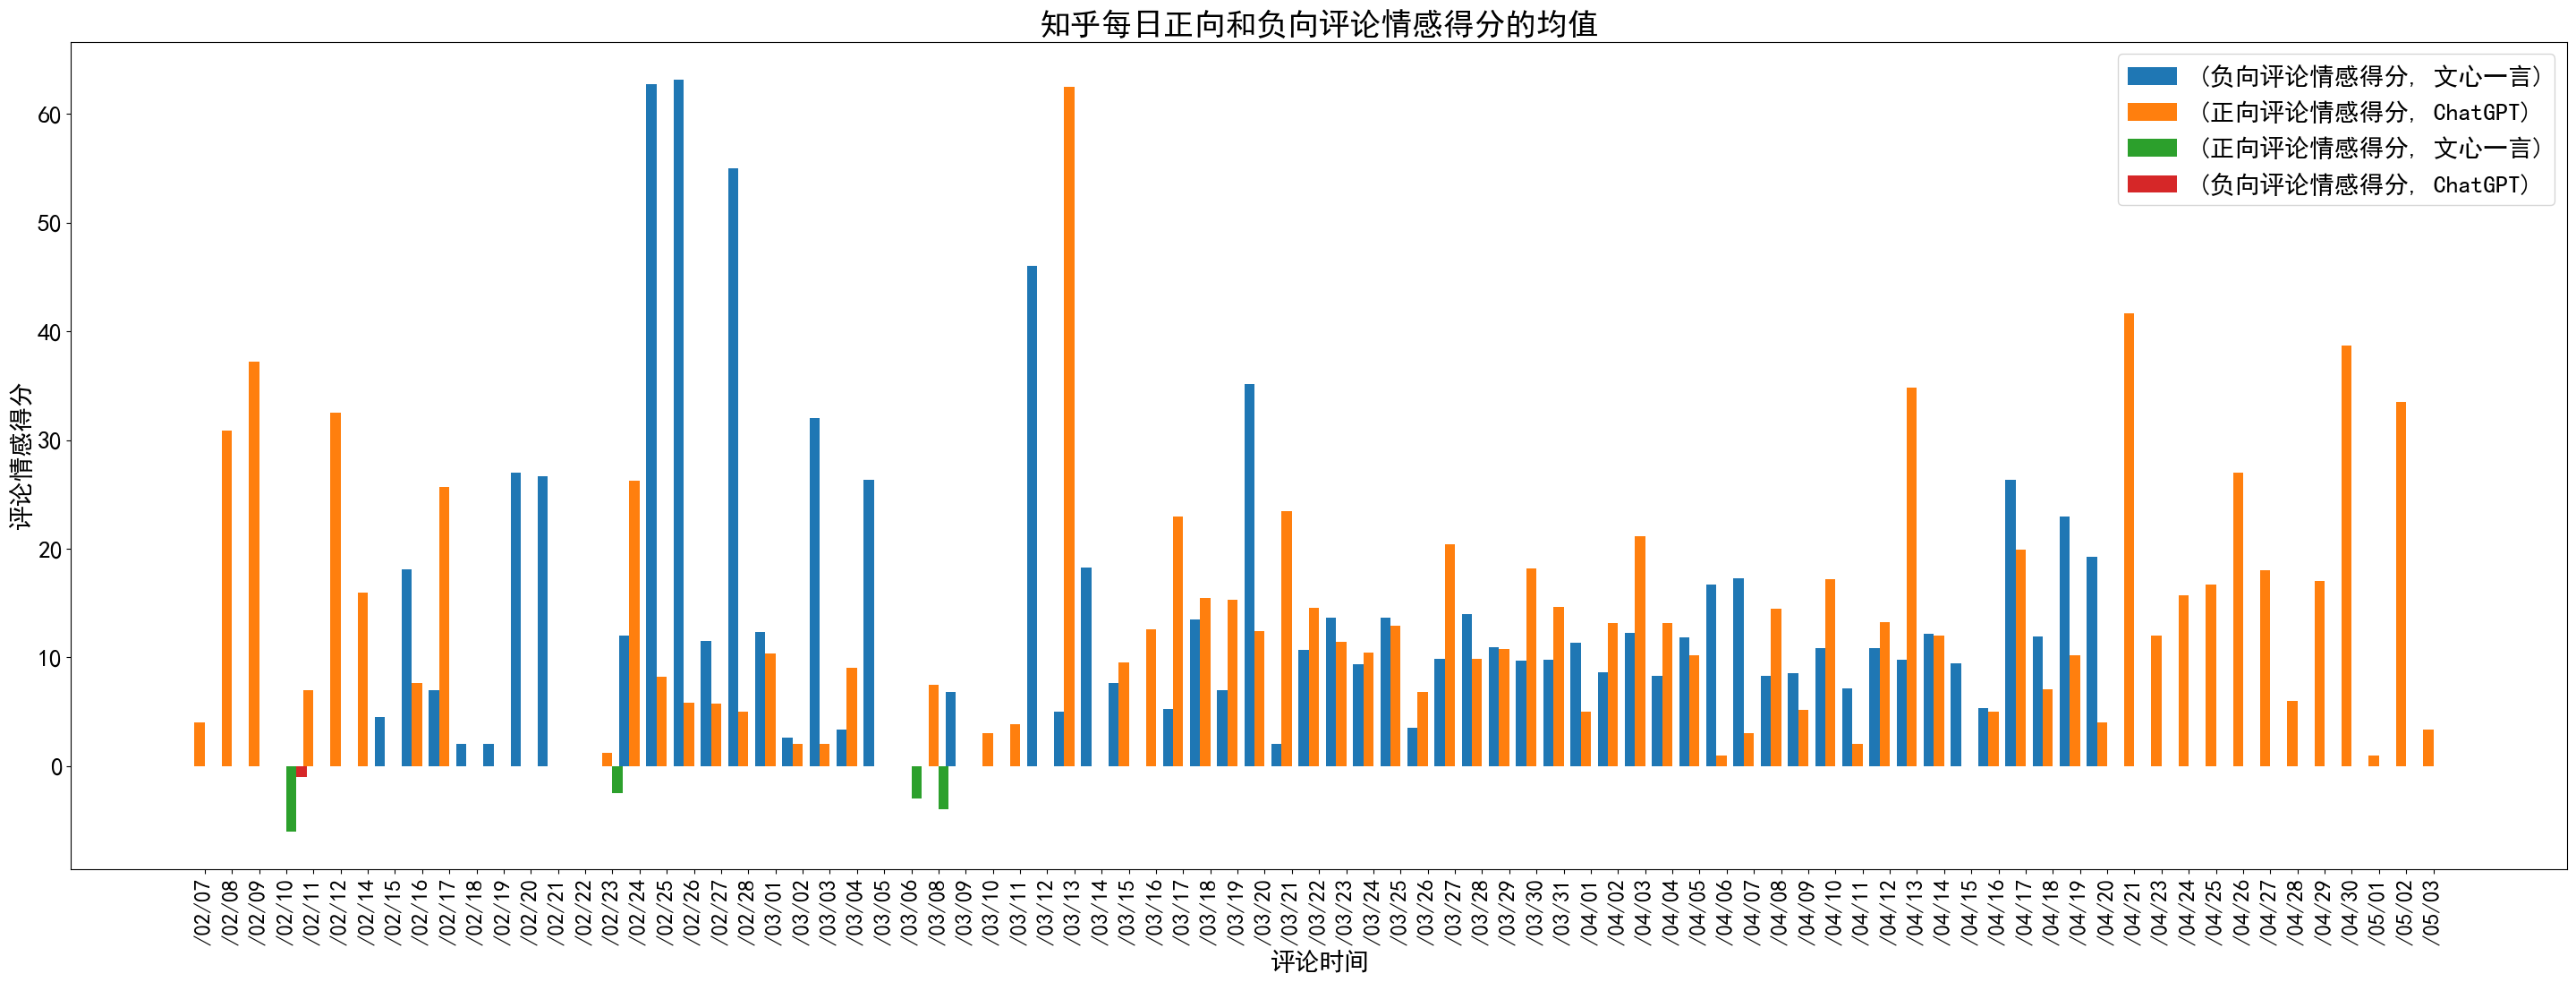

In [6]:
#绘制 每个平台的用户 对于不同评论对象的 每日平均的 正负向评论情感分变化

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 加载数据
data = pd.read_csv(r"C:\py study\data ana hw\情感分析绘图\merged_file_zh.csv")


# 将评论时间转换为日期格式
data['评论时间'] = pd.to_datetime(data['评论时间'], format='%Y/%m/%d')

# 进行分组计算，分别计算正向评论情感得分和负向评论情感得分的均值
grouped = data.groupby([pd.Grouper(key='评论时间', freq='D'), '评论对象'])['评论情感得分'].mean().reset_index()
grouped['正向评论情感得分'] = grouped['评论情感得分'].apply(lambda x: x if x > 0 else 0)
grouped['负向评论情感得分'] = grouped['评论情感得分'].apply(lambda x: x if x < 0 else 0)

# 将数据重构为透视表
pivot_table = pd.pivot_table(grouped, values=['正向评论情感得分', '负向评论情感得分'], index='评论时间', columns='评论对象')

# 绘制柱状图
#ax = pivot_table.plot(kind='bar', figsize=(36, 12), width=1)
ax = pivot_table.plot(kind='bar', figsize=(36, 12), width=1.5)
# 设置坐标轴范围和刻度
# 自动设置 y 轴刻度范围
ax.autoscale()
ax.set_xticklabels(pivot_table.index.strftime('/%m/%d'), rotation=90)

# 设置坐标轴标签和标题
ax.set_xlabel('评论时间',fontsize=20)
ax.set_ylabel('评论情感得分',fontsize=20)
ax.set_title('知乎每日正向和负向评论情感得分的均值',fontsize=25)
ax.tick_params(axis='y', labelsize=20)
ax.tick_params(axis='x', labelsize=18)

# 添加图例
# 添加图例
handles, labels = ax.get_legend_handles_labels()
new_labels = list(set(labels))
ax.legend(handles, new_labels, prop={'size': 20})

# 显示图形
plt.show()

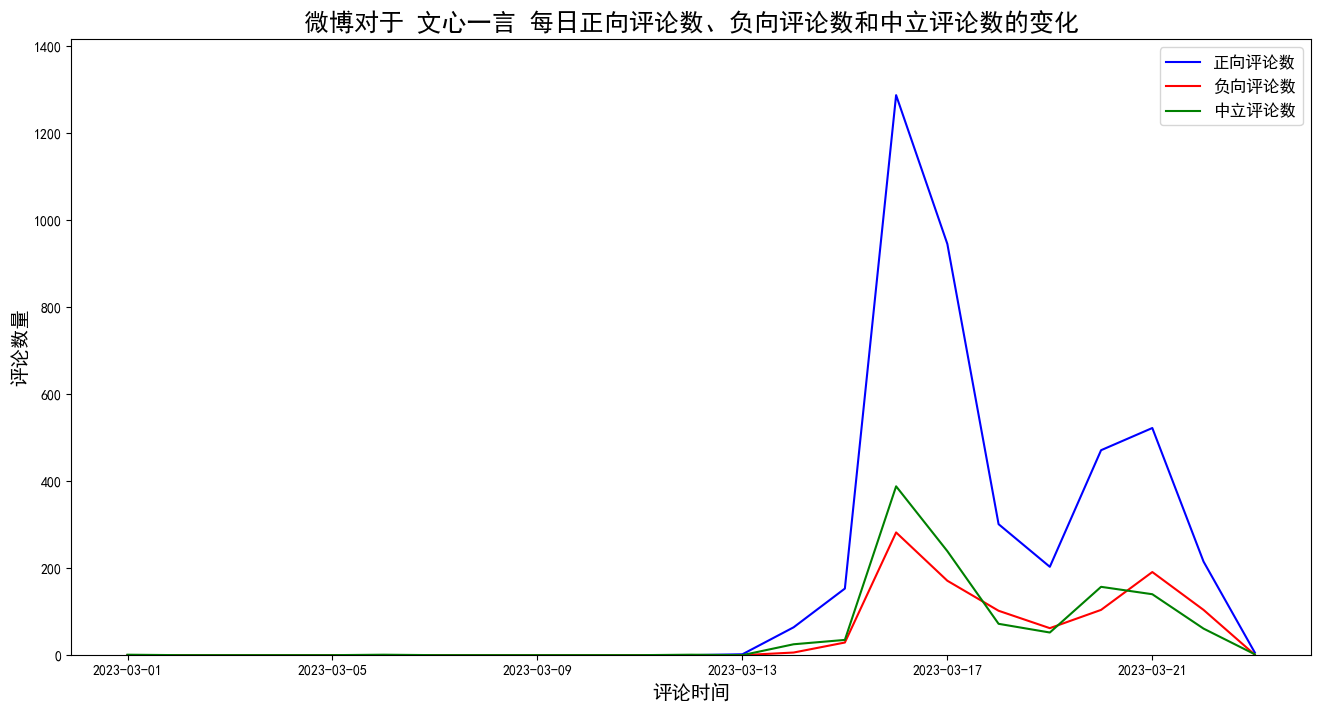

In [16]:
#不同平台，对于不同评论对象的正向/负向/中立评论数量变化趋势统计
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 加载数据并转换评论时间格式
df = pd.read_csv("C:\py study\data ana hw\情感分析绘图\merged_file_wb.csv", parse_dates=['评论时间'], infer_datetime_format=True)

# 定义一个自定义函数来计算每天的评论数量
def count_comments(df):
    count_positive = (df['评论情感得分'] > 0).sum()
    count_negative = (df['评论情感得分'] < 0).sum()
    count_neutral = (df['评论情感得分'] == 0).sum()
    return pd.Series([count_positive, count_negative, count_neutral], index=['正向评论数', '负向评论数', '中立评论数'])

# 使用 pivot_table 函数计算每日正向评论数、负向评论数和中立评论数
daily_comments = df[df['评论对象'] == '文心一言'].groupby(pd.Grouper(key='评论时间', freq='D')).apply(count_comments)
# 删除没有数据的日期
daily_comments = daily_comments.dropna()

# 绘制折线图
fig, ax = plt.subplots(figsize=(16, 8))

# 手动指定每条线的颜色
ax.plot(daily_comments.index, daily_comments['正向评论数'], color='blue', label='正向评论数')
ax.plot(daily_comments.index, daily_comments['负向评论数'], color='red', label='负向评论数')
ax.plot(daily_comments.index, daily_comments['中立评论数'], color='green', label='中立评论数')

# 设置图形标题、坐标轴标签和图例，并调整字体大小
ax.set_title('微博对于 文心一言 每日正向评论数、负向评论数和中立评论数的变化', fontsize=18)
ax.set_xlabel('评论时间', fontsize=14)
ax.set_ylabel('评论数量', fontsize=14)
ax.legend(fontsize=12)

# 调整坐标轴范围
ax.set_ylim(0, max(daily_comments.max()) * 1.1)


# 显示图形
plt.show()

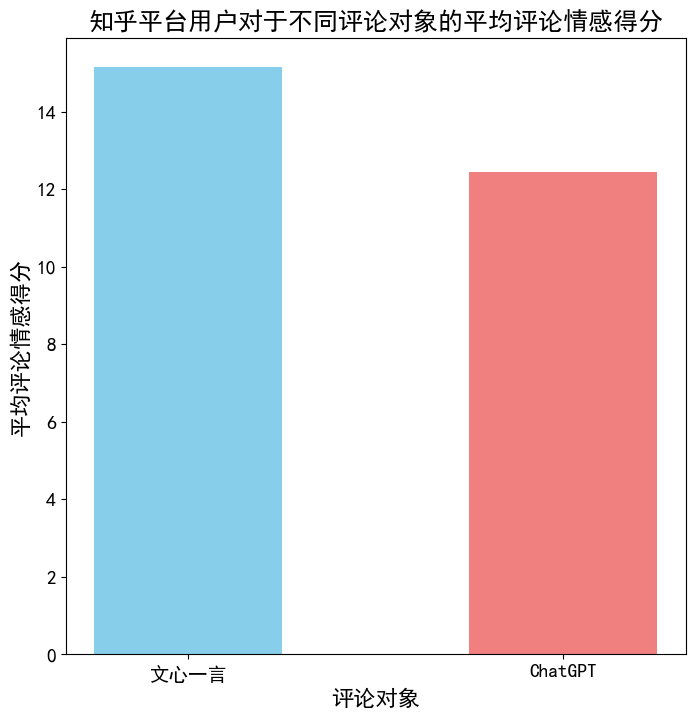

In [5]:
#绘制平台的总体平均情感得分
import pandas as pd
import matplotlib.pyplot as plt

# 读取CSV文件
df = pd.read_csv(r"C:\py study\data ana hw\情感分析绘图\merged_file_2.csv")

# 筛选出B站平台的评论，并按评论对象分组，计算平均情感得分
df_bilibili = df[df['用户所属平台'] == '知乎'].groupby('评论对象')['评论情感得分'].mean()

# 绘制柱状图
fig, ax = plt.subplots(figsize=(8, 8))
ax.bar(['文心一言', 'ChatGPT'], df_bilibili[['文心一言', 'ChatGPT']], color=['skyblue', 'lightcoral'], width=0.5)
# 修改刻度和文字大小
ax.tick_params(labelsize=14)
ax.set_xlabel('评论对象', fontsize=16)
ax.set_ylabel('平均评论情感得分', fontsize=16)
ax.set_title('知乎平台用户对于不同评论对象的平均评论情感得分', fontsize=18)

plt.show()